# MF33 Cross-Section Covariance Parser — Test Notebook

Tests parsing, round-trip, conversion to `CrossSectionCovariance`, and plotting.

In [1]:
from kika.endf.parsers import parse_endf_file
from kika.endf.parsers.parse_mf33 import parse_mf33_mt
from kika.cov.cross_section_covariance import CrossSectionCovariance
from kika.plotting.covariance import plot_covariance_heatmap
import numpy as np
import matplotlib.pyplot as plt

## 1. Parse MF33 from ENDF file

In [2]:
endf = parse_endf_file('/home/MONLEON-JUAN/kika/kika/endf/files/n-026_Fe_056.endf')
mf33 = endf.mf[33]
print(f'MF33: {len(mf33.sections)} MT sections')
print(f'Available MTs: {sorted(mf33.sections.keys())}')

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 12, 14]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


MF33: 39 MT sections
Available MTs: [1, 2, 4, 16, 22, 28, 102, 103, 104, 105, 106, 107, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 649, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 849]


In [3]:
# Summary of all parsed sections
lb_counts = {}
for mt_num, mt_sec in sorted(mf33.sections.items()):
    lumped = f' (lumped→MT{mt_sec.lumped_mt})' if mt_sec.is_lumped_component else ''
    nsub = mt_sec.num_subsections
    if nsub > 0:
        ni_total = sum(len(s.ni_records) for s in mt_sec.subsections)
        nc_total = sum(len(s.nc_records) for s in mt_sec.subsections)
        lbs = set()
        for s in mt_sec.subsections:
            for r in s.ni_records:
                lbs.add(int(r.lb))
                lb_counts[int(r.lb)] = lb_counts.get(int(r.lb), 0) + 1
        print(f'  MT{mt_num:>4}: {nsub} subsections, {ni_total} NI, {nc_total} NC, LBs={sorted(lbs)}{lumped}')
    else:
        print(f'  MT{mt_num:>4}: empty{lumped}')

print(f'\nLB type counts across all sections: {dict(sorted(lb_counts.items()))}')

  MT   1: 1 subsections, 3 NI, 0 NC, LBs=[1, 5, 8]
  MT   2: 2 subsections, 2 NI, 0 NC, LBs=[5, 6]
  MT   4: 1 subsections, 1 NI, 0 NC, LBs=[5]
  MT  16: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT  22: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT  28: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 102: 1 subsections, 1 NI, 0 NC, LBs=[5]
  MT 103: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 104: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 105: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 106: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 107: 10 subsections, 11 NI, 0 NC, LBs=[5, 6, 8]
  MT 600: empty (lumped→MT103)
  MT 601: empty (lumped→MT103)
  MT 602: empty (lumped→MT103)
  MT 603: empty (lumped→MT103)
  MT 604: empty (lumped→MT103)
  MT 605: empty (lumped→MT103)
  MT 606: empty (lumped→MT103)
  MT 607: empty (lumped→MT103)
  MT 608: empty (lumped→MT103)
  MT 609: empty (lumped→MT103)
  MT 610: empty (lumped→MT103)
  MT 611: empty (lumped→MT103)
  MT 612: empty

## 2. Round-trip verification (parse → `__str__()` → re-parse)

In [4]:
errors = 0
tested = 0
for mt_num, mt_sec in mf33.sections.items():
    output = str(mt_sec)
    output_lines = output.split('\n')
    try:
        reparsed = parse_mf33_mt(output_lines, mt_num)
    except Exception as e:
        print(f'MT{mt_num}: REPARSE FAILED: {e}')
        errors += 1
        continue

    if len(mt_sec.subsections) != len(reparsed.subsections):
        print(f'MT{mt_num}: subsection count mismatch')
        errors += 1
        continue

    for i, (o, r) in enumerate(zip(mt_sec.subsections, reparsed.subsections)):
        if len(o.ni_records) != len(r.ni_records):
            print(f'MT{mt_num} sub{i}: NI count mismatch')
            errors += 1
        for j, (oni, rni) in enumerate(zip(o.ni_records, r.ni_records)):
            if oni.lb != rni.lb:
                print(f'MT{mt_num} sub{i} ni{j}: LB mismatch {oni.lb} vs {rni.lb}')
                errors += 1
    tested += 1

print(f'Round-trip: {tested} MT sections tested, {errors} errors')

Round-trip: 39 MT sections tested, 0 errors


## 3. Convert to CrossSectionCovariance

In [5]:
# Collect all non-lumped MT sections into one CrossSectionCovariance
all_cov = CrossSectionCovariance(energy_unit='eV')
for mt_num, mt_sec in sorted(mf33.sections.items()):
    if mt_sec.is_lumped_component:
        continue
    partial = mt_sec.to_xs_covmat()
    for i in range(len(partial.matrices)):
        all_cov.add_matrix(
            partial.isotope_rows[i], partial.reaction_rows[i],
            partial.isotope_cols[i], partial.reaction_cols[i],
            partial.matrices[i],
            energy_grid=partial.energy_grids[i],
            is_relative=partial.is_relative[i],
        )

print(f'Total covariance matrices: {len(all_cov.matrices)}')
print(f'Per-matrix energy grids: {len(all_cov.energy_grids)}')
print(f'Grid sizes: {sorted(set(len(g) for g in all_cov.energy_grids))}')

Total covariance matrices: 85
Per-matrix energy grids: 85
Grid sizes: [16, 22, 23, 25, 28, 29, 31, 32, 33, 36, 38, 39, 43, 44, 45, 47, 48, 50, 51, 52, 56, 57, 58, 59, 63, 66, 77, 78]


In [6]:
# Inspect diagonal (self-covariance) matrices
print('Diagonal blocks (self-covariance):')
for i in range(len(all_cov.matrices)):
    if all_cov.reaction_rows[i] == all_cov.reaction_cols[i]:
        m = all_cov.matrices[i]
        grid = all_cov.energy_grids[i]
        diag = m.diagonal()
        rel_std = np.sqrt(np.maximum(diag, 0))
        print(f'  MT{all_cov.reaction_rows[i]:>4}: {m.shape[0]:>4} groups, '
              f'E=[{grid[0]:.0e}..{grid[-1]:.0e}], '
              f'rel_std=[{rel_std.min():.3f}..{rel_std.max():.3f}] '
              f'({rel_std.min()*100:.1f}%..{rel_std.max()*100:.1f}%)')

Diagonal blocks (self-covariance):
  MT   1:   46 groups, E=[1e-05..2e+07], rel_std=[0.005..0.050] (0.5%..5.0%)
  MT   2:   15 groups, E=[1e-05..2e+07], rel_std=[0.043..0.084] (4.3%..8.4%)
  MT   4:   15 groups, E=[1e-05..2e+07], rel_std=[0.000..0.058] (0.0%..5.8%)
  MT  16:   15 groups, E=[1e-05..2e+07], rel_std=[0.000..0.078] (0.0%..7.8%)
  MT  22:   28 groups, E=[1e-05..2e+07], rel_std=[0.000..0.441] (0.0%..44.1%)
  MT  28:   21 groups, E=[1e-05..2e+07], rel_std=[0.000..0.475] (0.0%..47.5%)
  MT 102:   15 groups, E=[1e-05..2e+07], rel_std=[0.029..0.190] (2.9%..19.0%)
  MT 103:   30 groups, E=[1e-05..2e+07], rel_std=[0.000..0.060] (0.0%..6.0%)
  MT 104:   24 groups, E=[1e-05..2e+07], rel_std=[0.000..0.802] (0.0%..80.2%)
  MT 105:   15 groups, E=[1e-05..2e+07], rel_std=[0.000..0.653] (0.0%..65.3%)
  MT 106:   15 groups, E=[1e-05..2e+07], rel_std=[0.000..0.661] (0.0%..66.1%)
  MT 107:   31 groups, E=[1e-05..2e+07], rel_std=[0.000..0.884] (0.0%..88.4%)


## 4. Correlation heatmaps

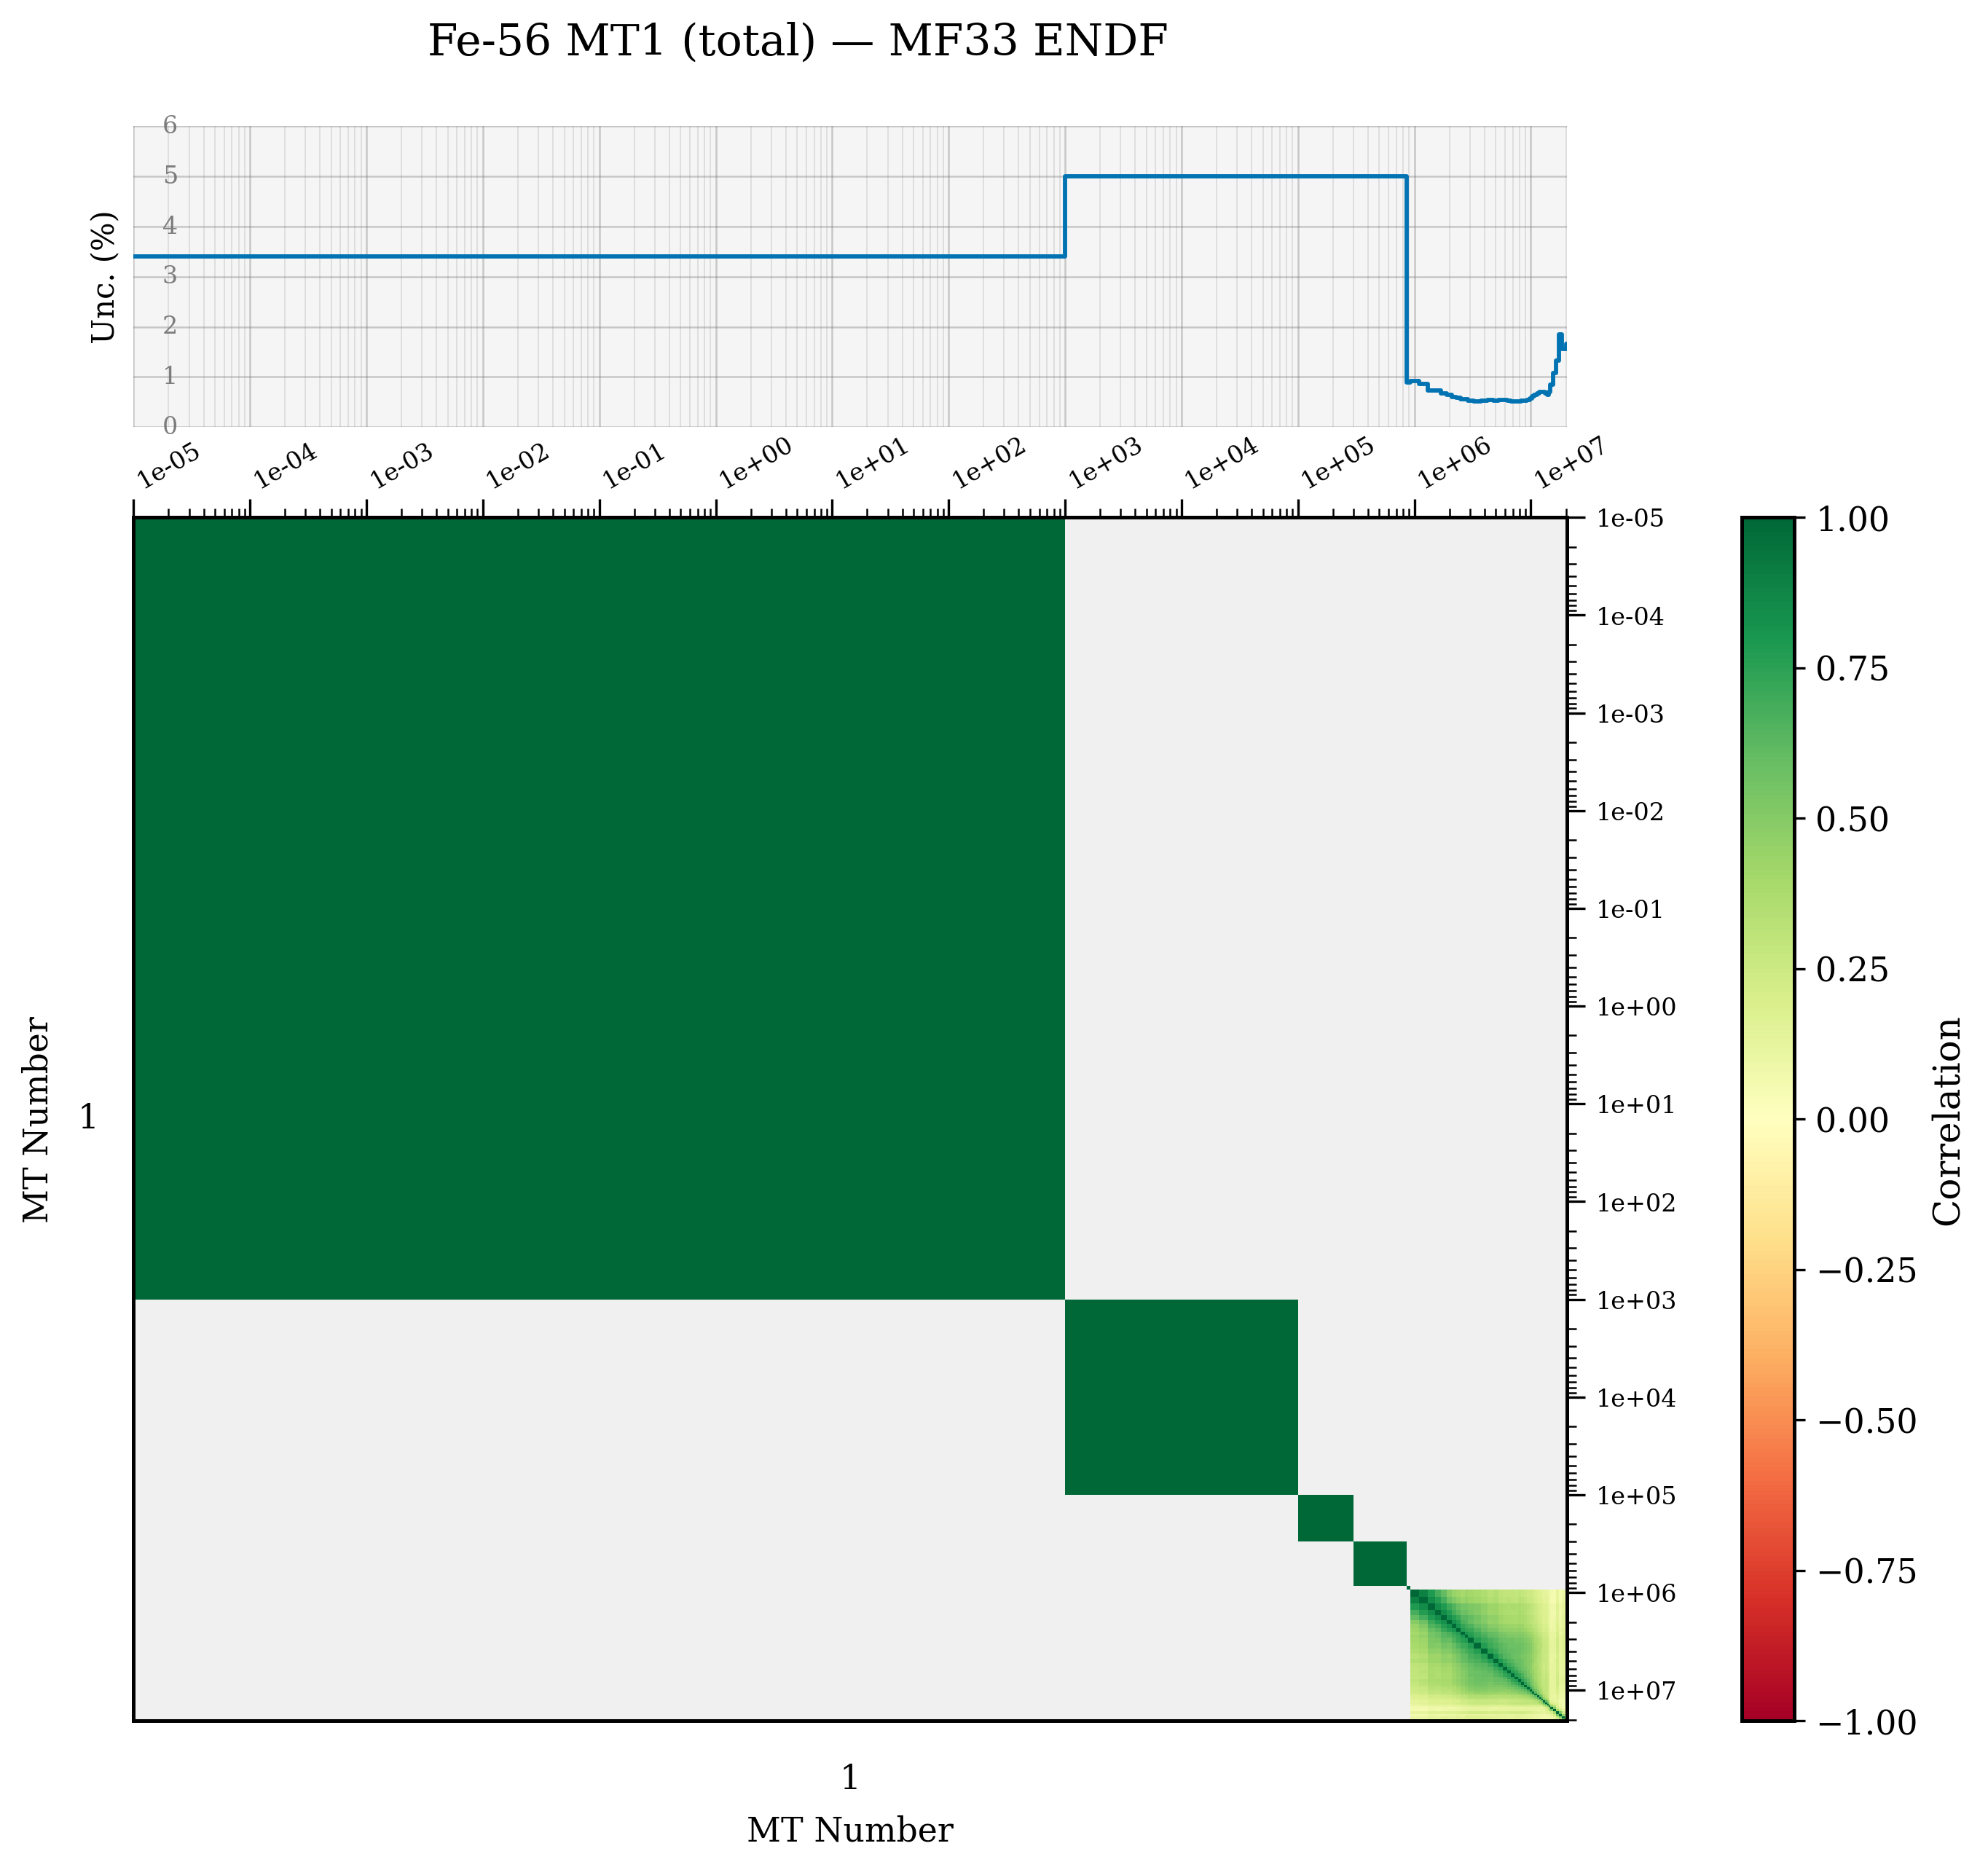

In [7]:
# MT1 (total) correlation heatmap
sub = all_cov.filter_by_reactions([1])
fig = plot_covariance_heatmap(sub, 26056, 1, matrix_type='corr', title='Fe-56 MT1 (total) — MF33 ENDF')
plt.show()

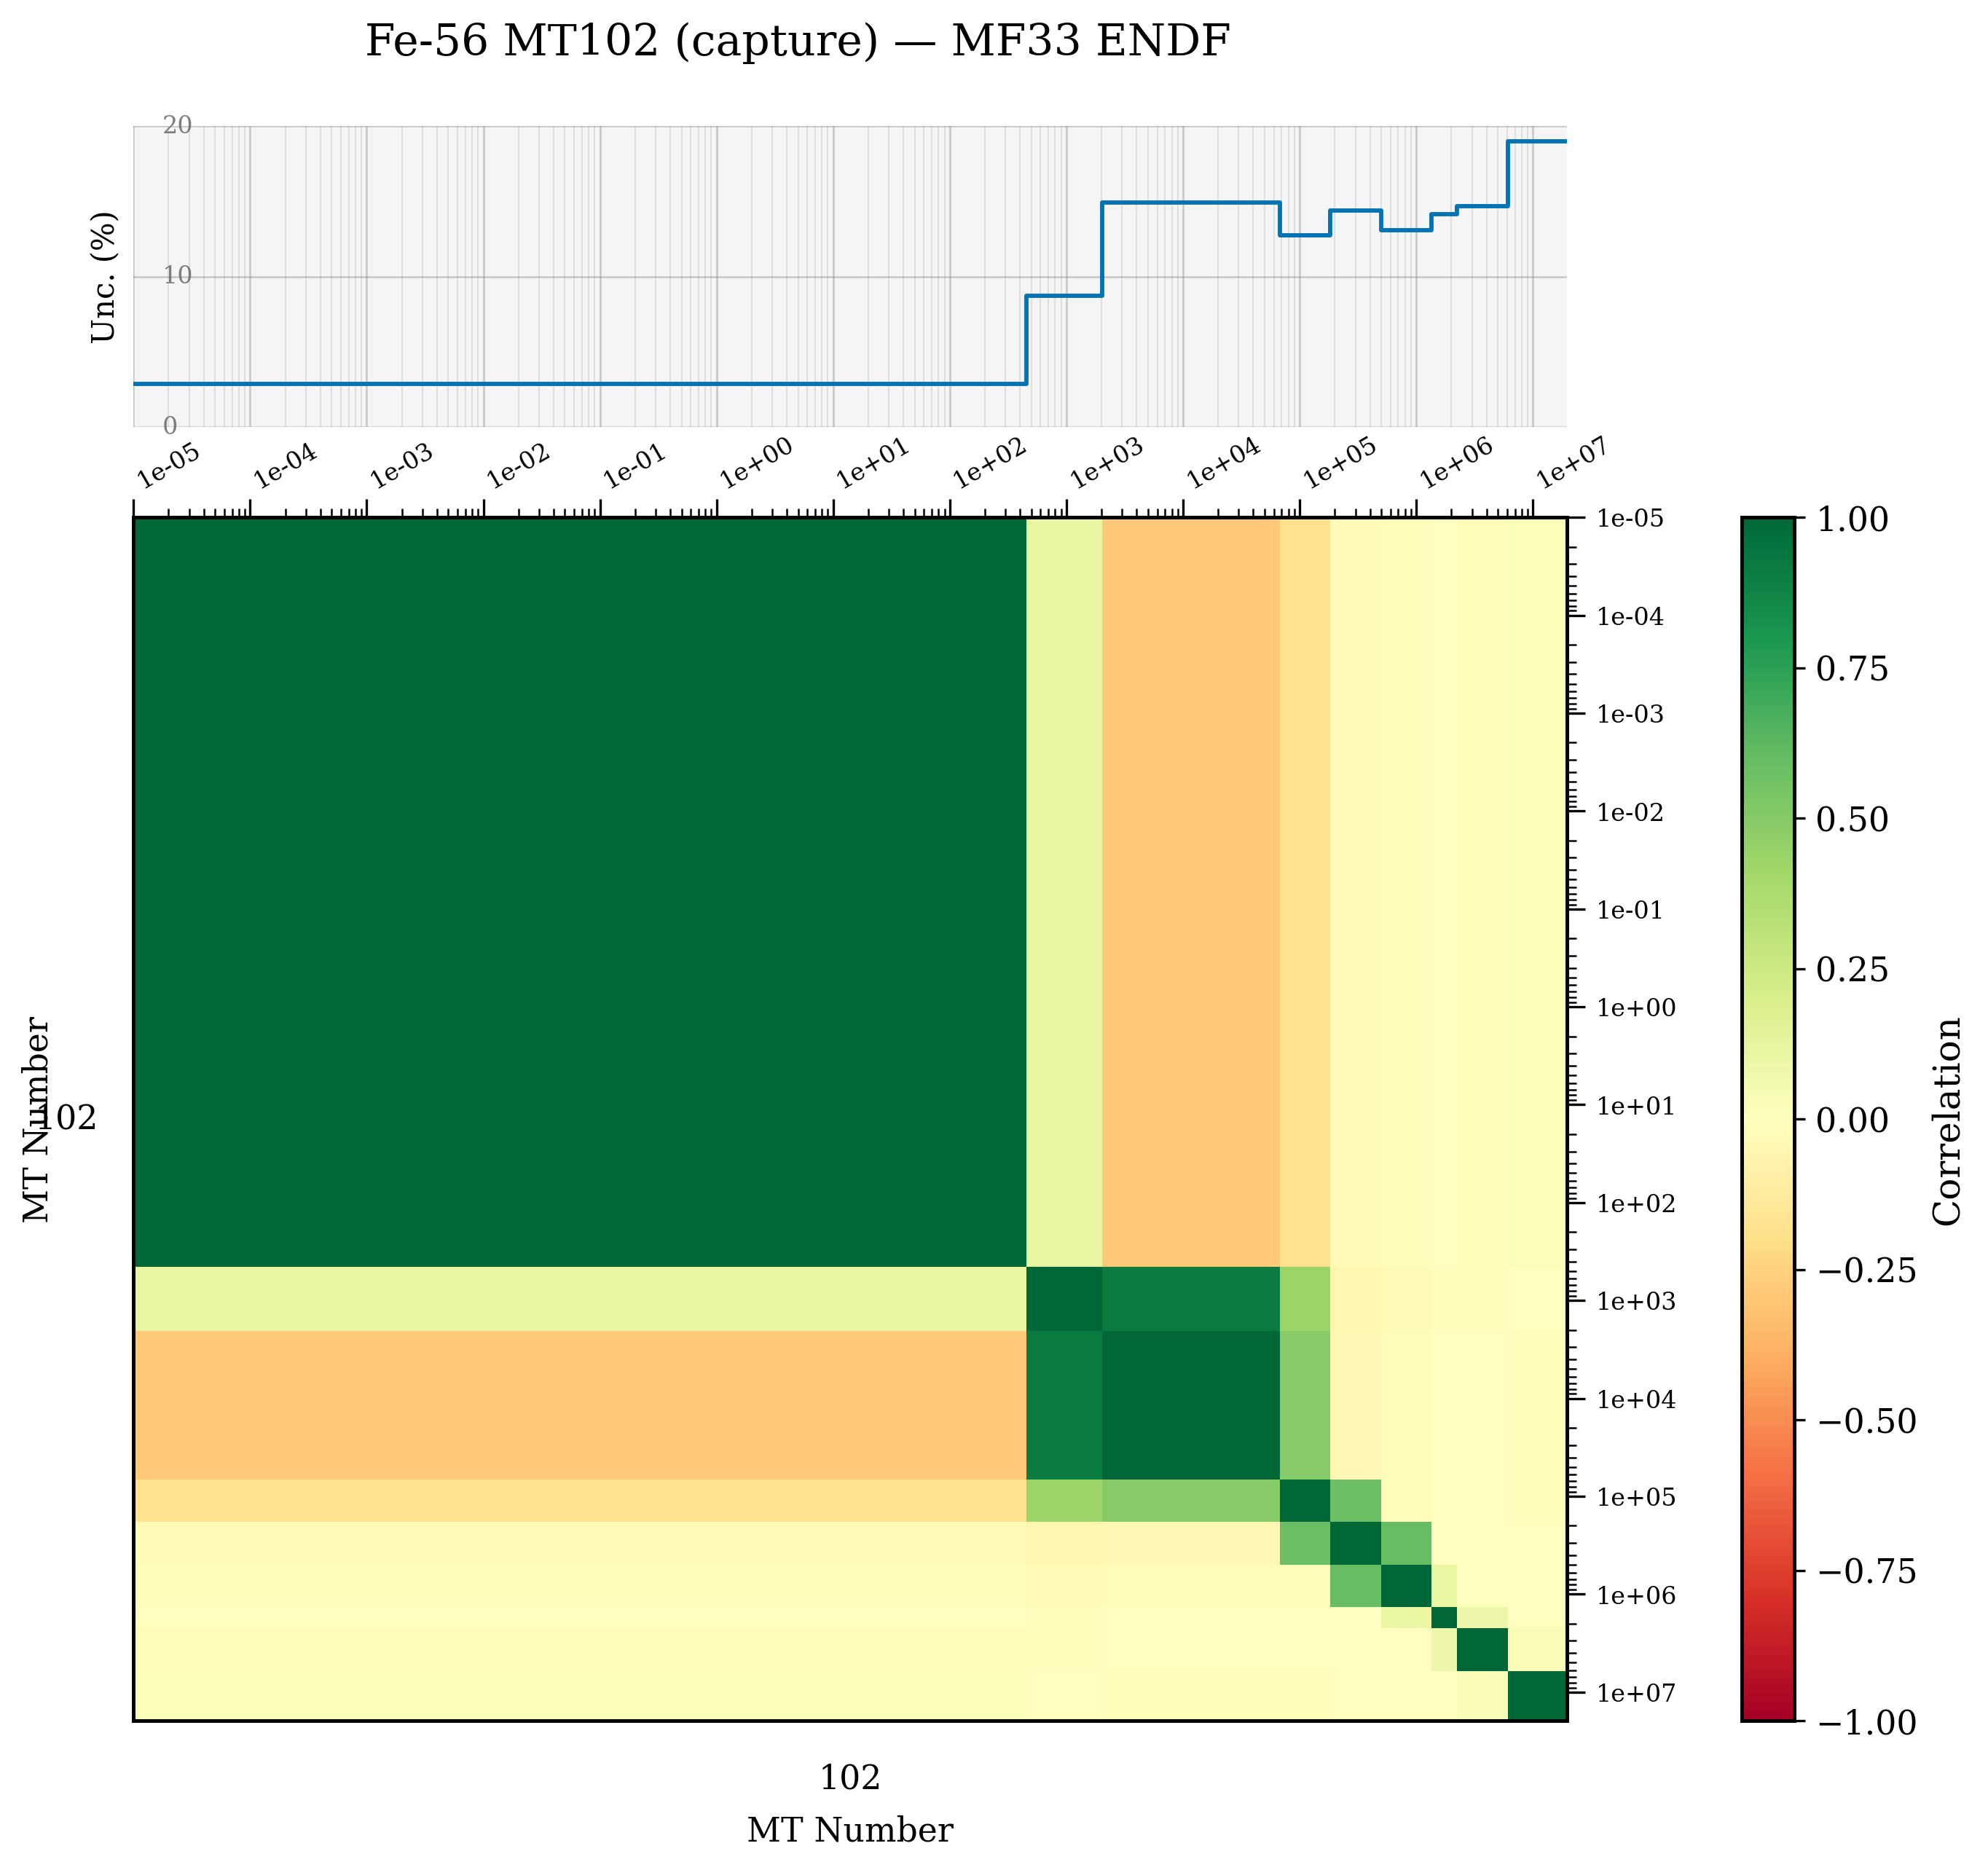

In [8]:
# MT102 (capture) correlation heatmap
sub102 = all_cov.filter_by_reactions([102])
fig = plot_covariance_heatmap(sub102, 26056, 102, matrix_type='corr', title='Fe-56 MT102 (capture) — MF33 ENDF')
plt.show()

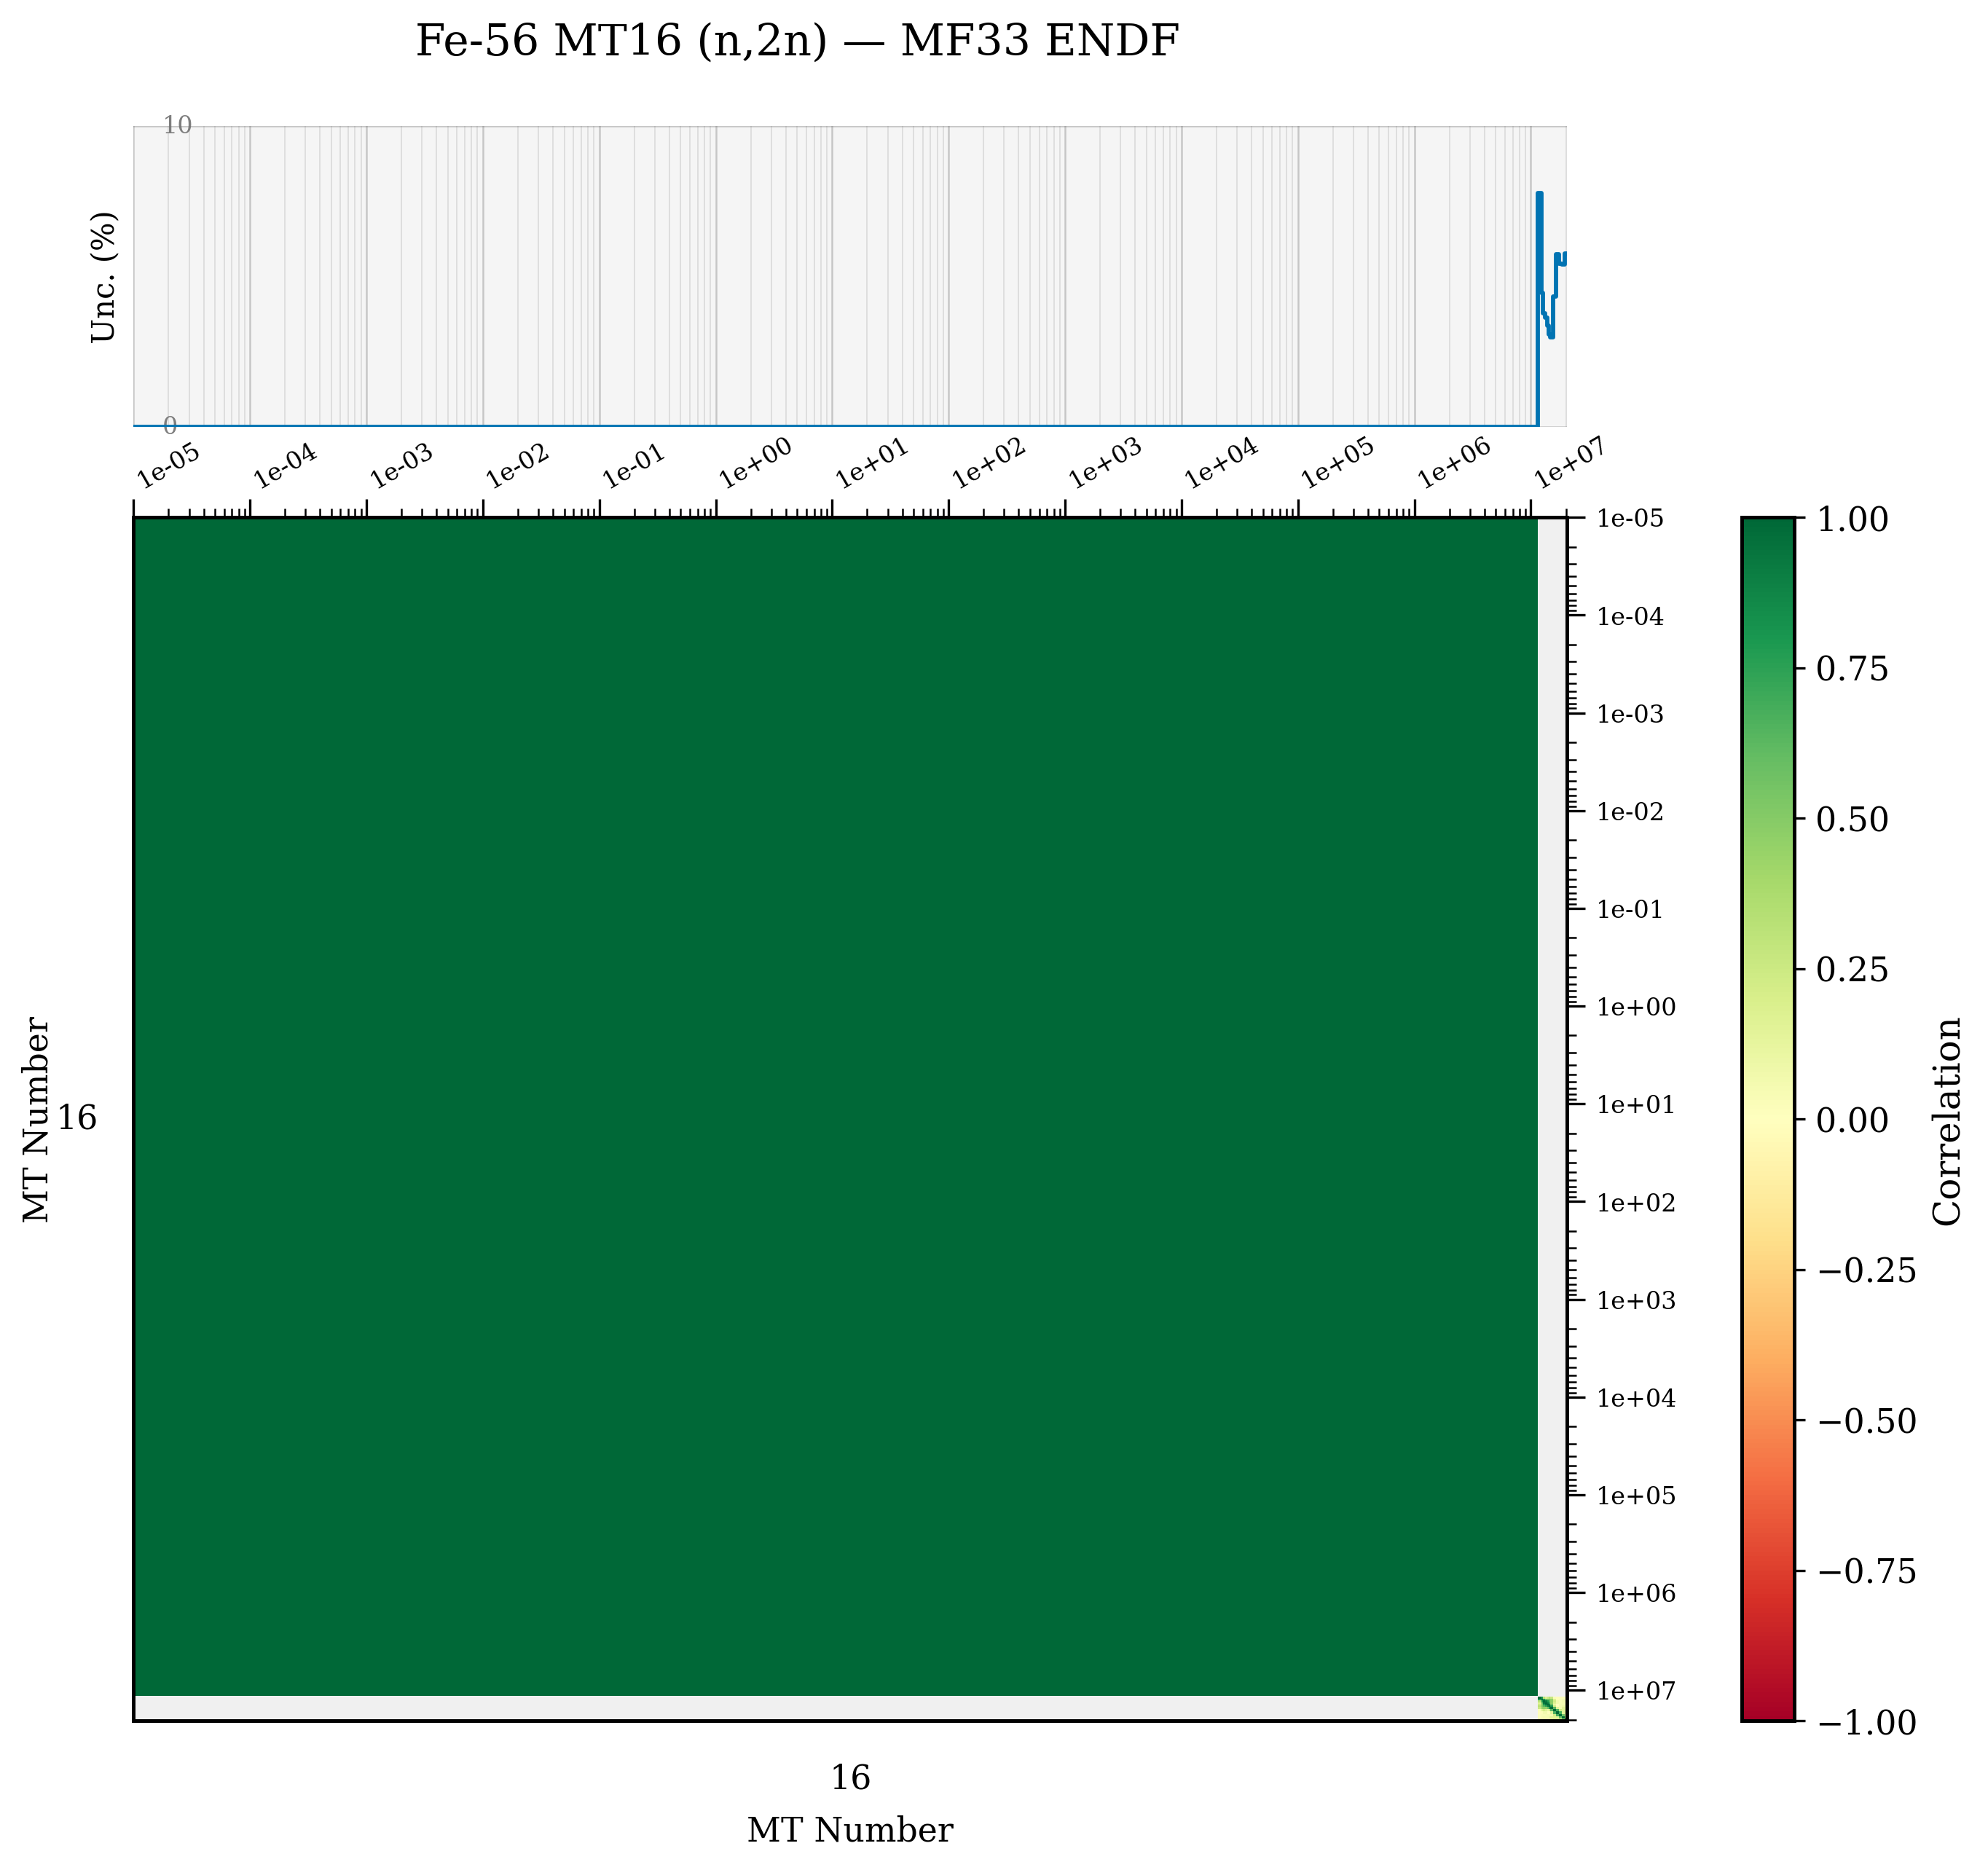

In [9]:
# MT16 (n,2n) correlation heatmap
sub16 = all_cov.filter_by_reactions([16])
fig = plot_covariance_heatmap(sub16, 26056, 16, matrix_type='corr', title='Fe-56 MT16 (n,2n) — MF33 ENDF')
plt.show()

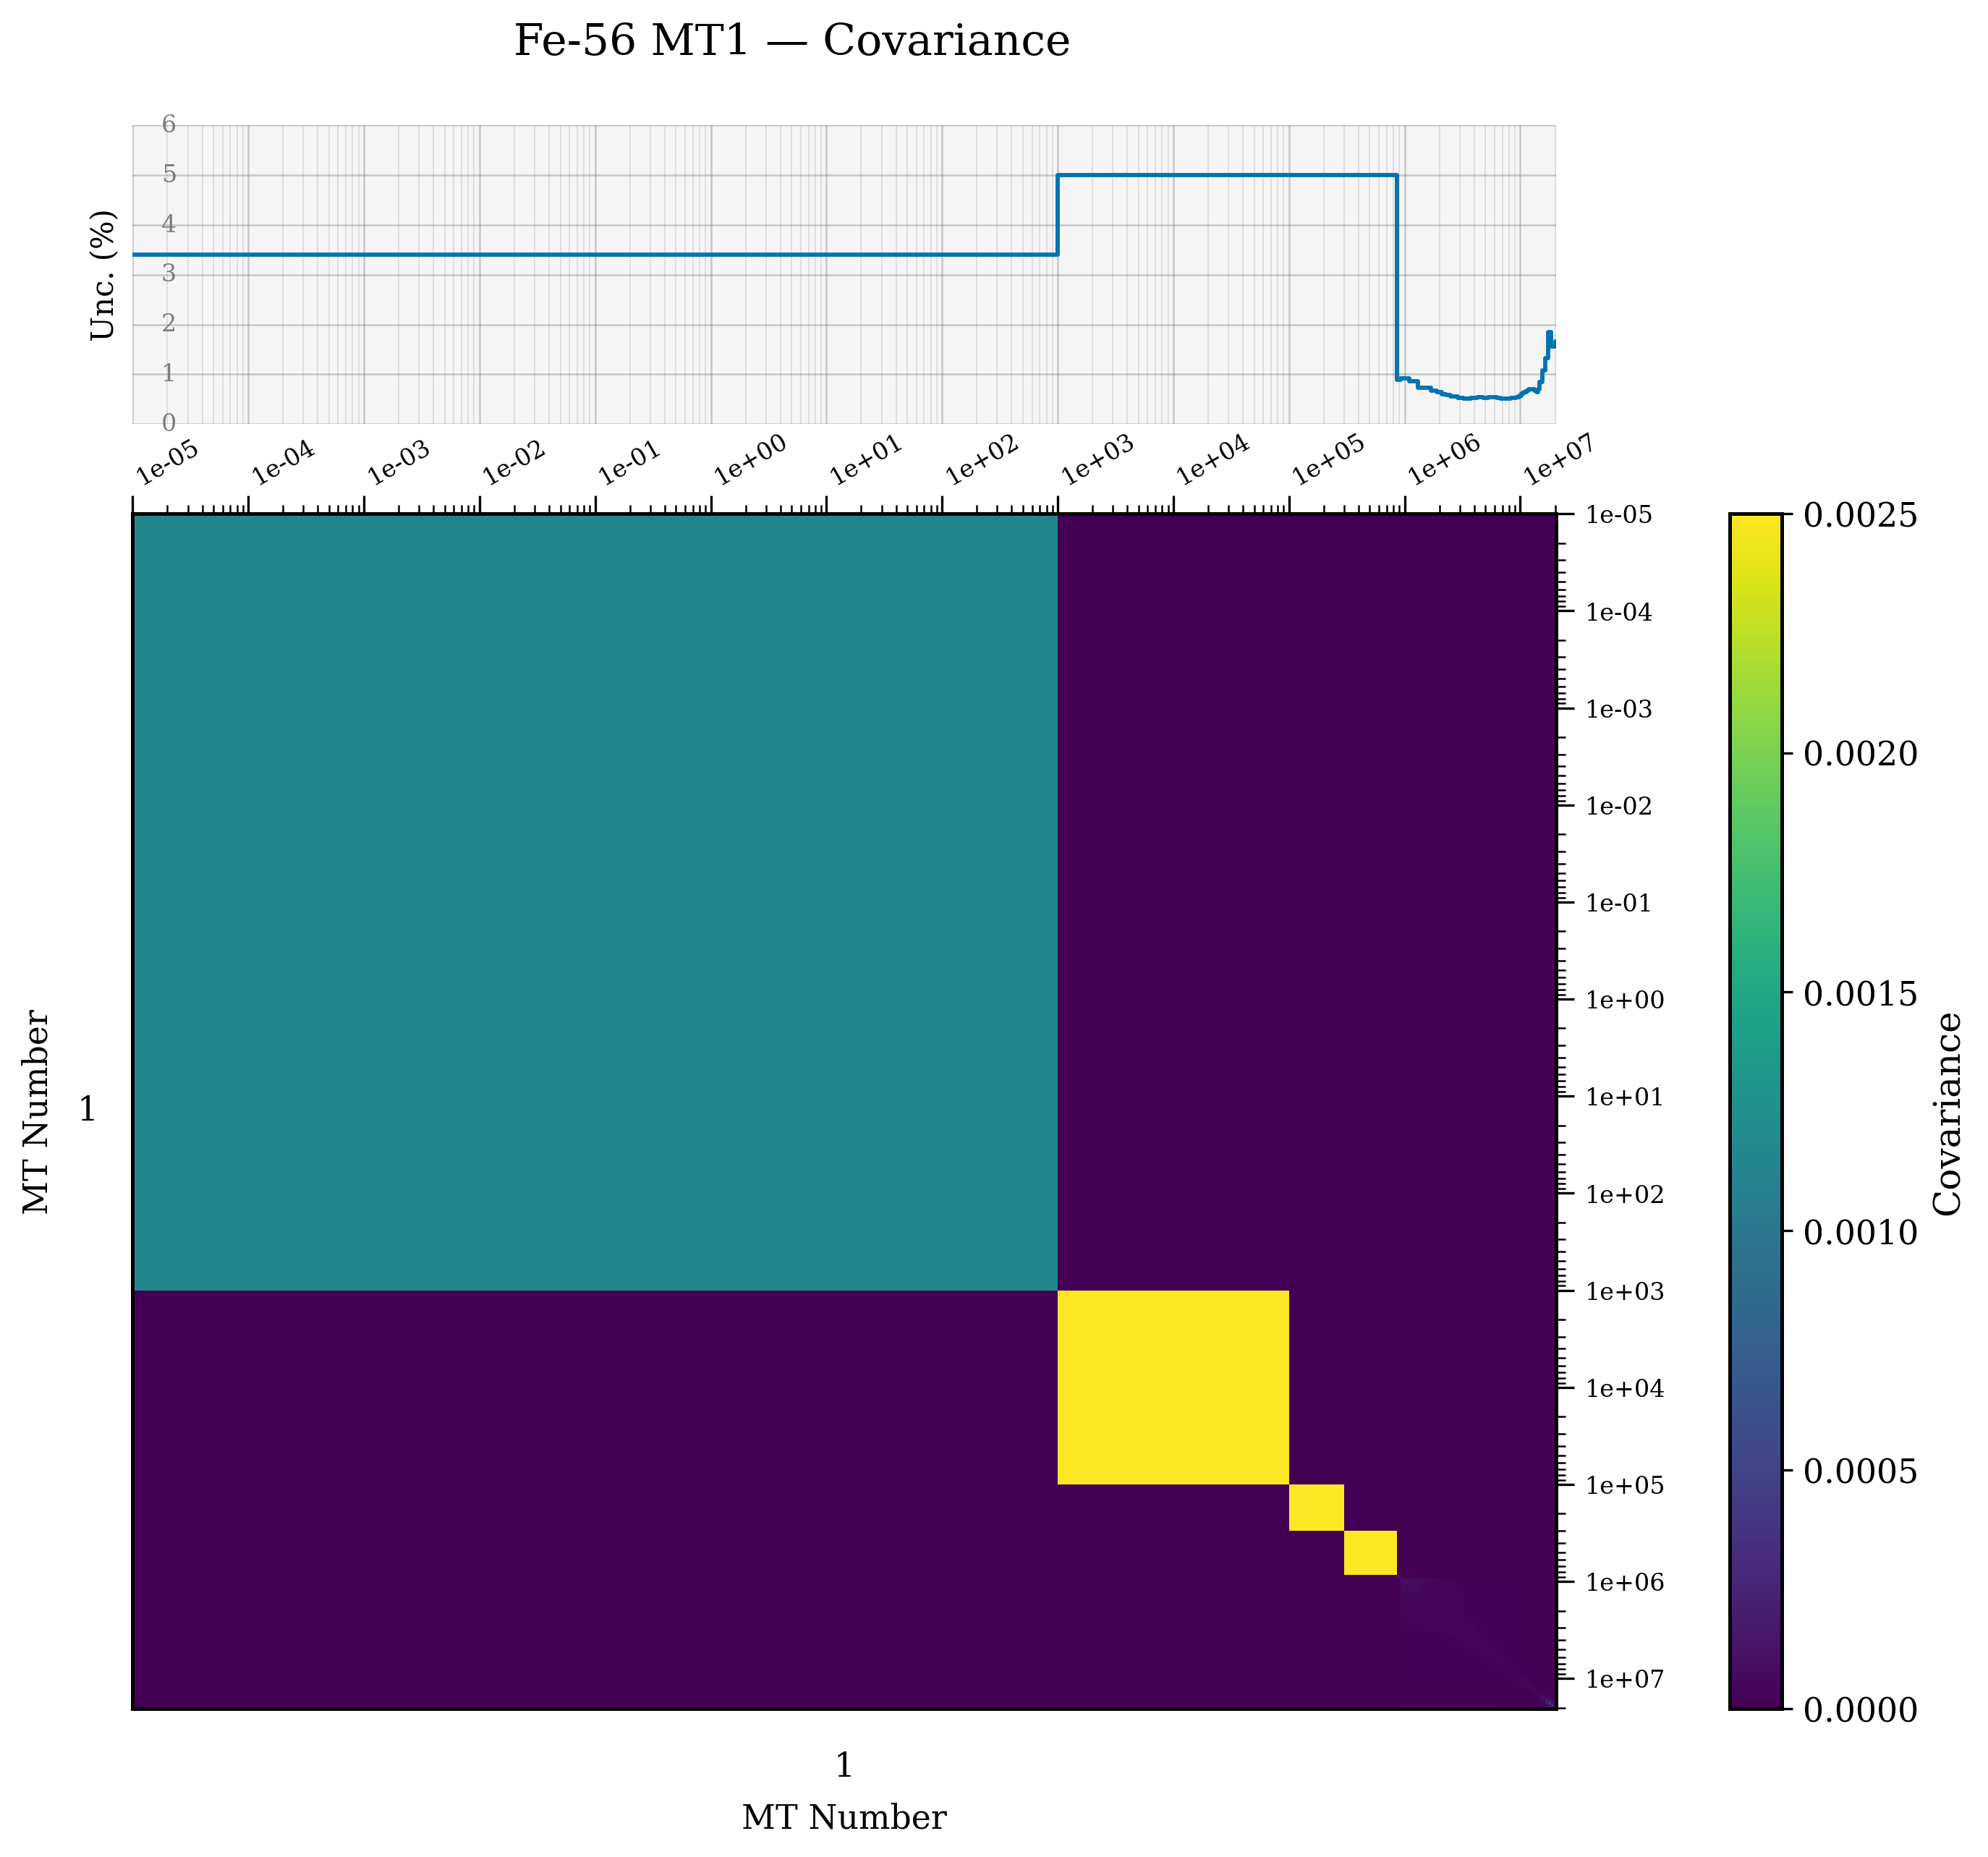

In [10]:
# Covariance heatmap (not correlation)
fig = plot_covariance_heatmap(sub, 26056, 1, matrix_type='cov', title='Fe-56 MT1 — Covariance')
plt.show()

## 5. O-16 (has NC-type LTY=0 records)

In [11]:
endf_o16 = parse_endf_file('/home/MONLEON-JUAN/kika/kika/endf/files/n-008_O_016.endf')
mf33_o16 = endf_o16.mf[33]
print(f'O-16 MF33: {len(mf33_o16.sections)} MT sections')

# Check NC records
for mt_num, mt_sec in sorted(mf33_o16.sections.items()):
    for sub in mt_sec.subsections:
        if sub.nc_records:
            for nc in sub.nc_records:
                if nc.lty == 0:
                    print(f'  MT{mt_num}: NC LTY=0, CI={nc.ci}, XMTI={nc.xmti}')

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 12, 13, 14]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


O-16 MF33: 48 MT sections
  MT1: NC LTY=0, CI=[1, 1], XMTI=[2, 800]
  MT4: NC LTY=0, CI=[1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], XMTI=[1, 2, 16, 22, 23, 28, 32, 41, 44, 45, 102, 103, 104, 105, 107, 108, 112.00000000000001]
  MT5: NC LTY=0, CI=[1, -1], XMTI=[1, 2]
  MT103: NC LTY=0, CI=[1, 1, 1, 1], XMTI=[600, 601, 602, 603]
  MT104: NC LTY=0, CI=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], XMTI=[650, 651, 652, 653, 654, 655, 656, 657, 658, 659]
  MT105: NC LTY=0, CI=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], XMTI=[700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 749]
  MT107: NC LTY=0, CI=[1, 1, 1, 1], XMTI=[800, 801, 802, 802.9999999999999]


O-16 MT2: 1588 groups


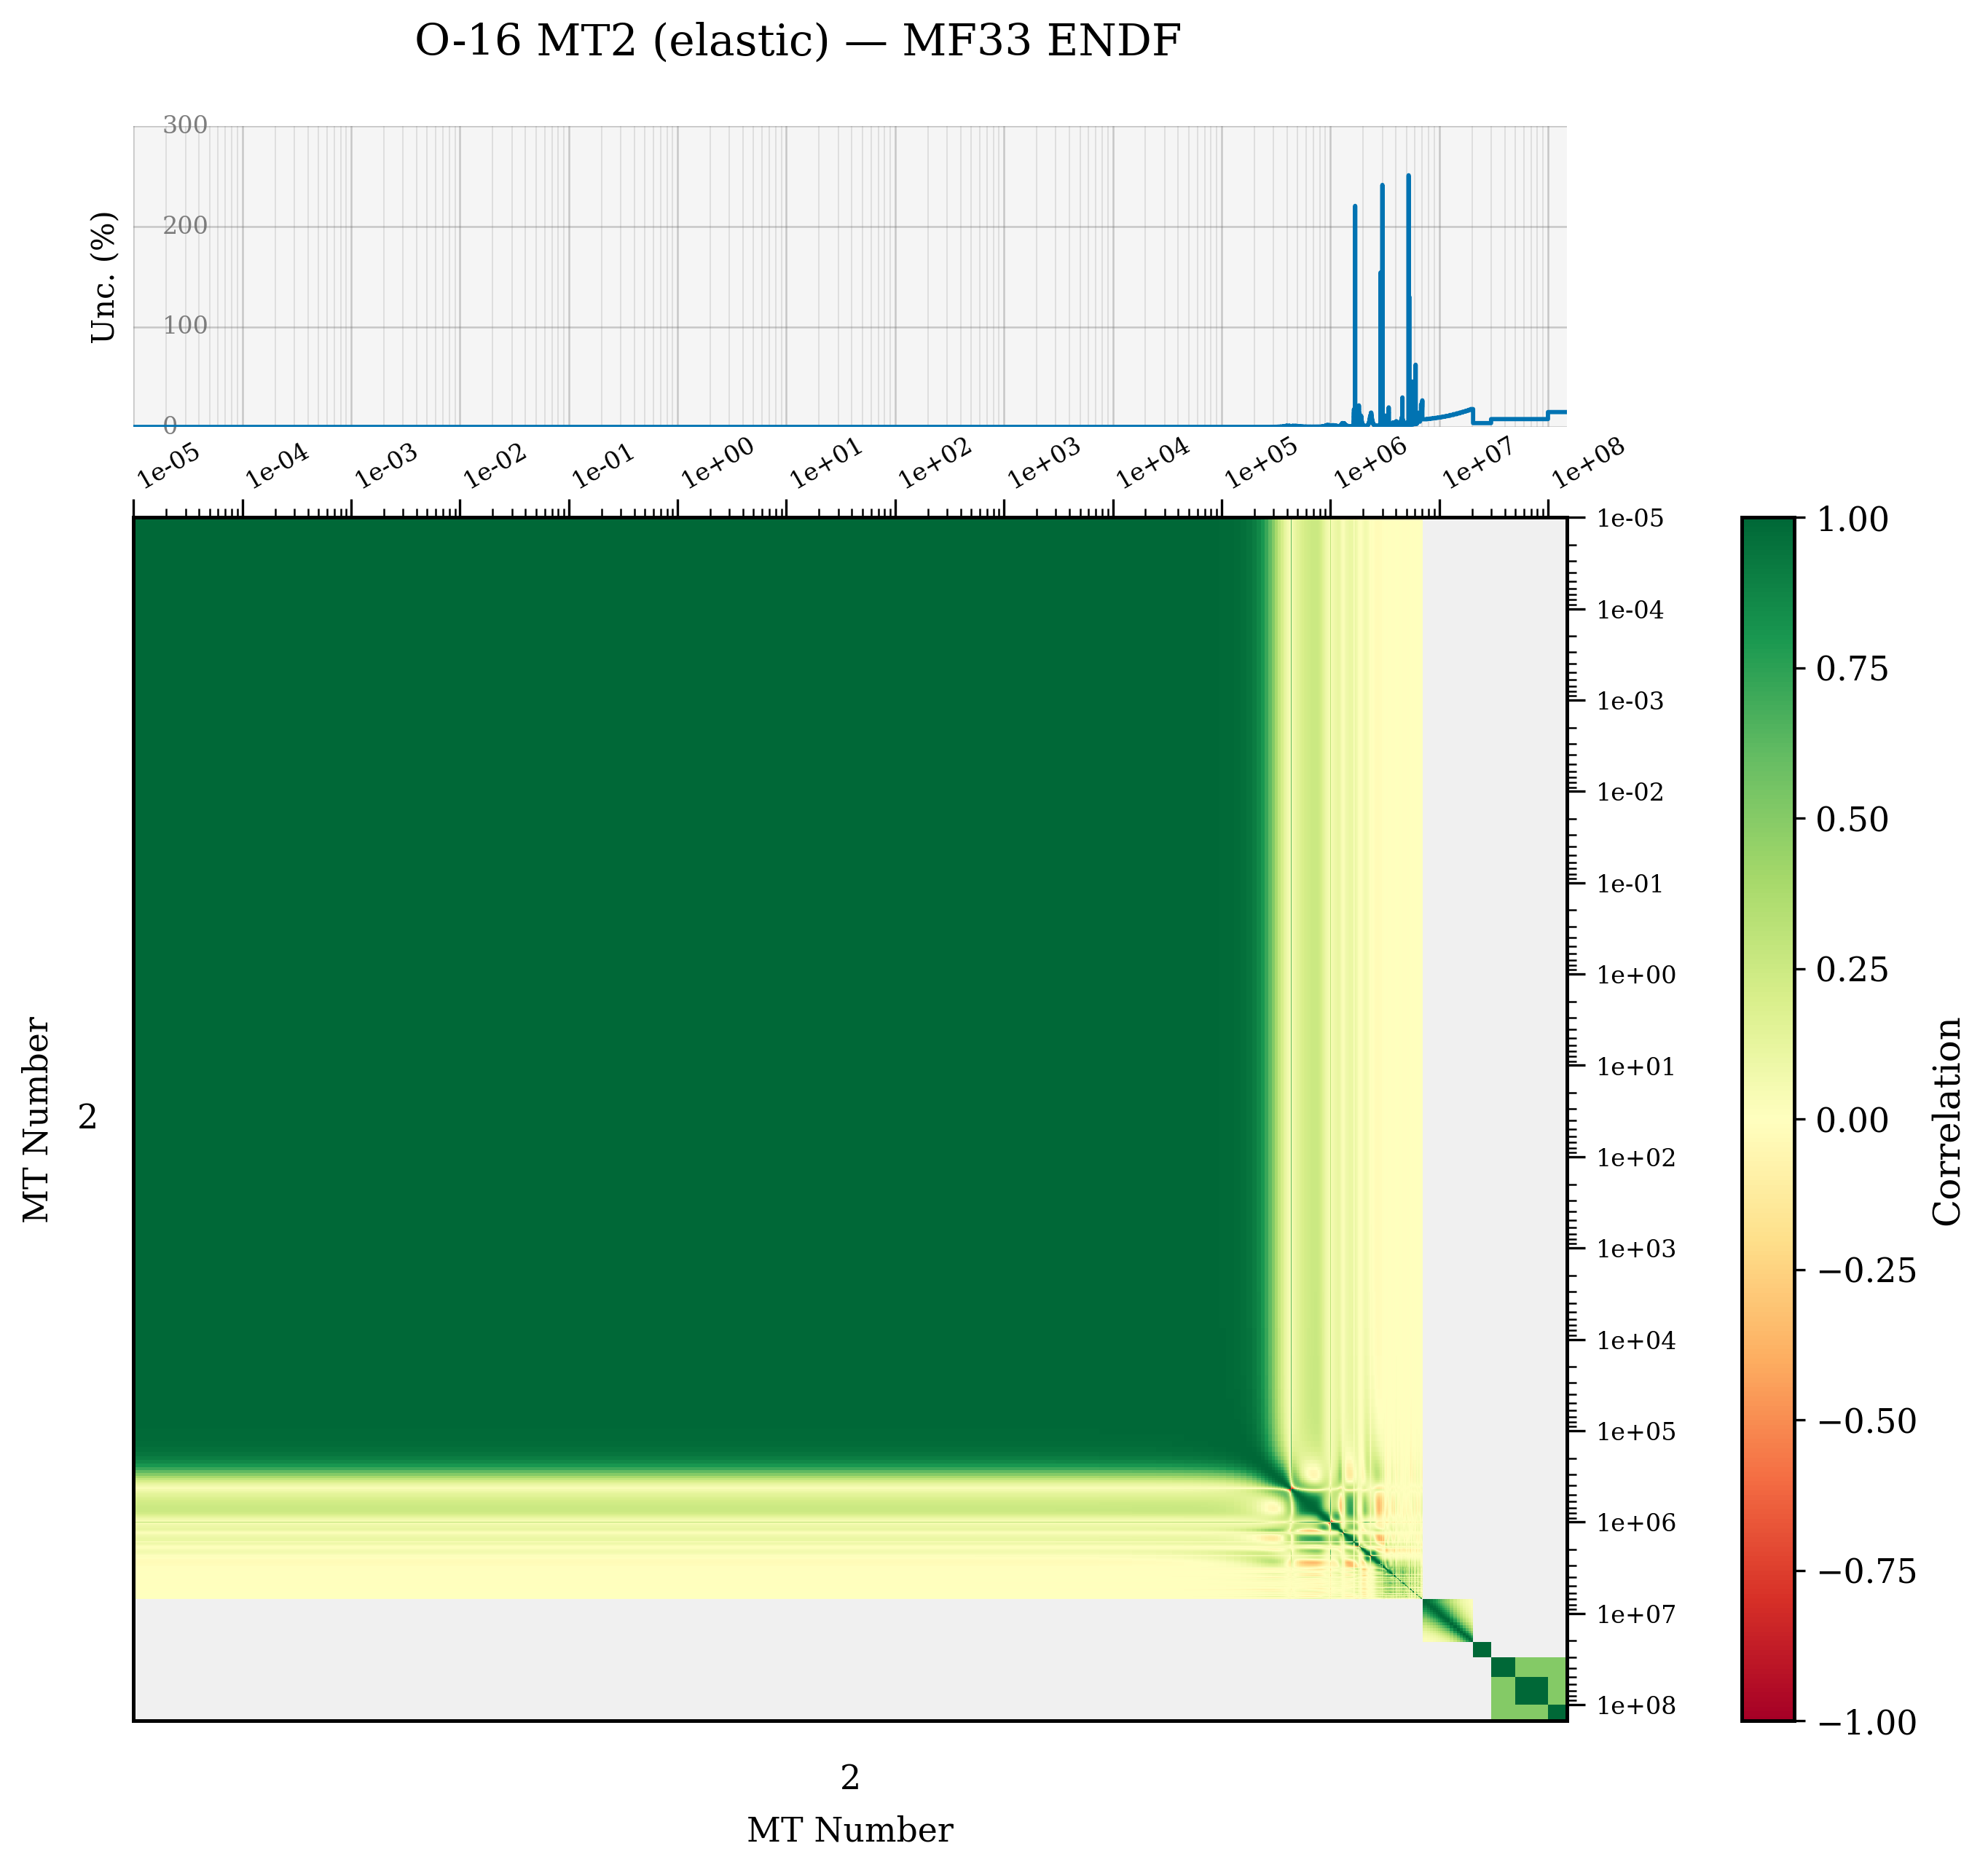

In [12]:
# O-16 MT2 (elastic) — large matrix
mt2_cov = mf33_o16.sections[2].to_xs_covmat()
sub_o16 = mt2_cov.filter_by_reactions([2])
print(f'O-16 MT2: {sub_o16.num_groups} groups')

fig = plot_covariance_heatmap(sub_o16, 8016, 2, matrix_type='corr', title='O-16 MT2 (elastic) — MF33 ENDF')
plt.show()

O-16 MT800: 1124 groups


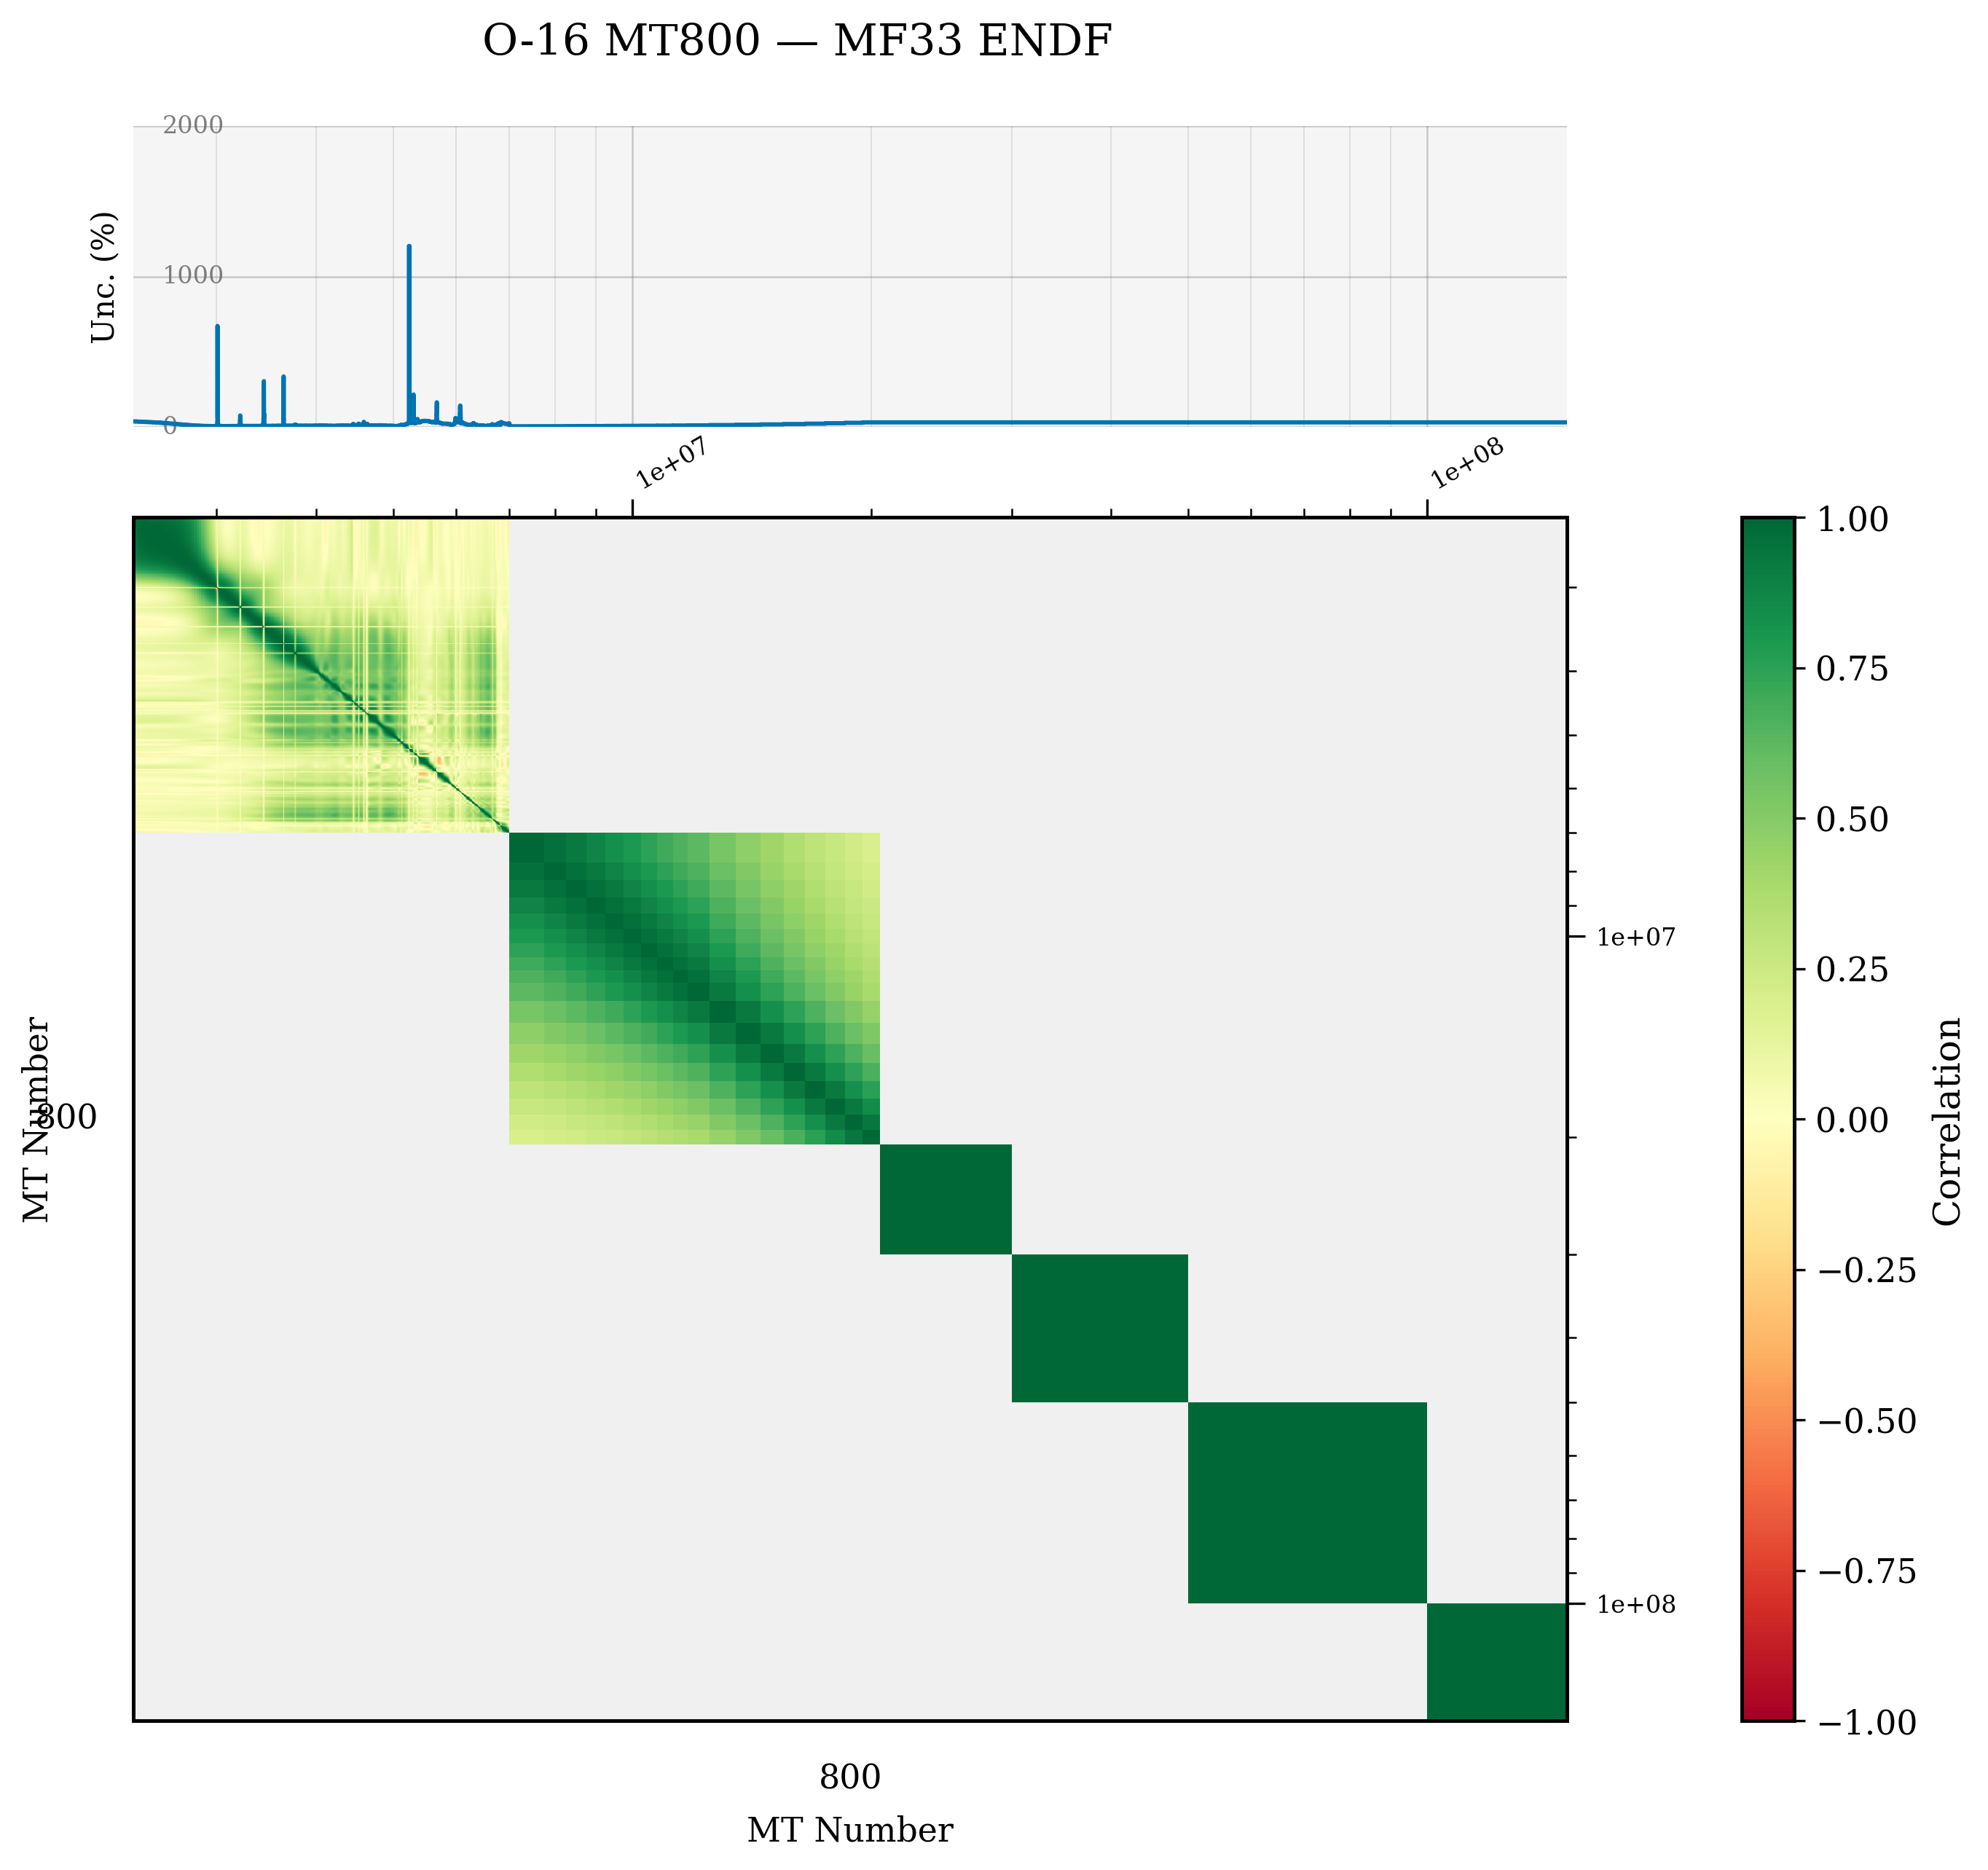

In [13]:
# O-16 MT800 — another large matrix
mt800_cov = mf33_o16.sections[800].to_xs_covmat()
sub800 = mt800_cov.filter_by_reactions([800])
print(f'O-16 MT800: {sub800.num_groups} groups')

fig = plot_covariance_heatmap(sub800, 8016, 800, matrix_type='corr', title='O-16 MT800 — MF33 ENDF')
plt.show()

## 6. Manual uncertainty plot (relative std from diagonal)

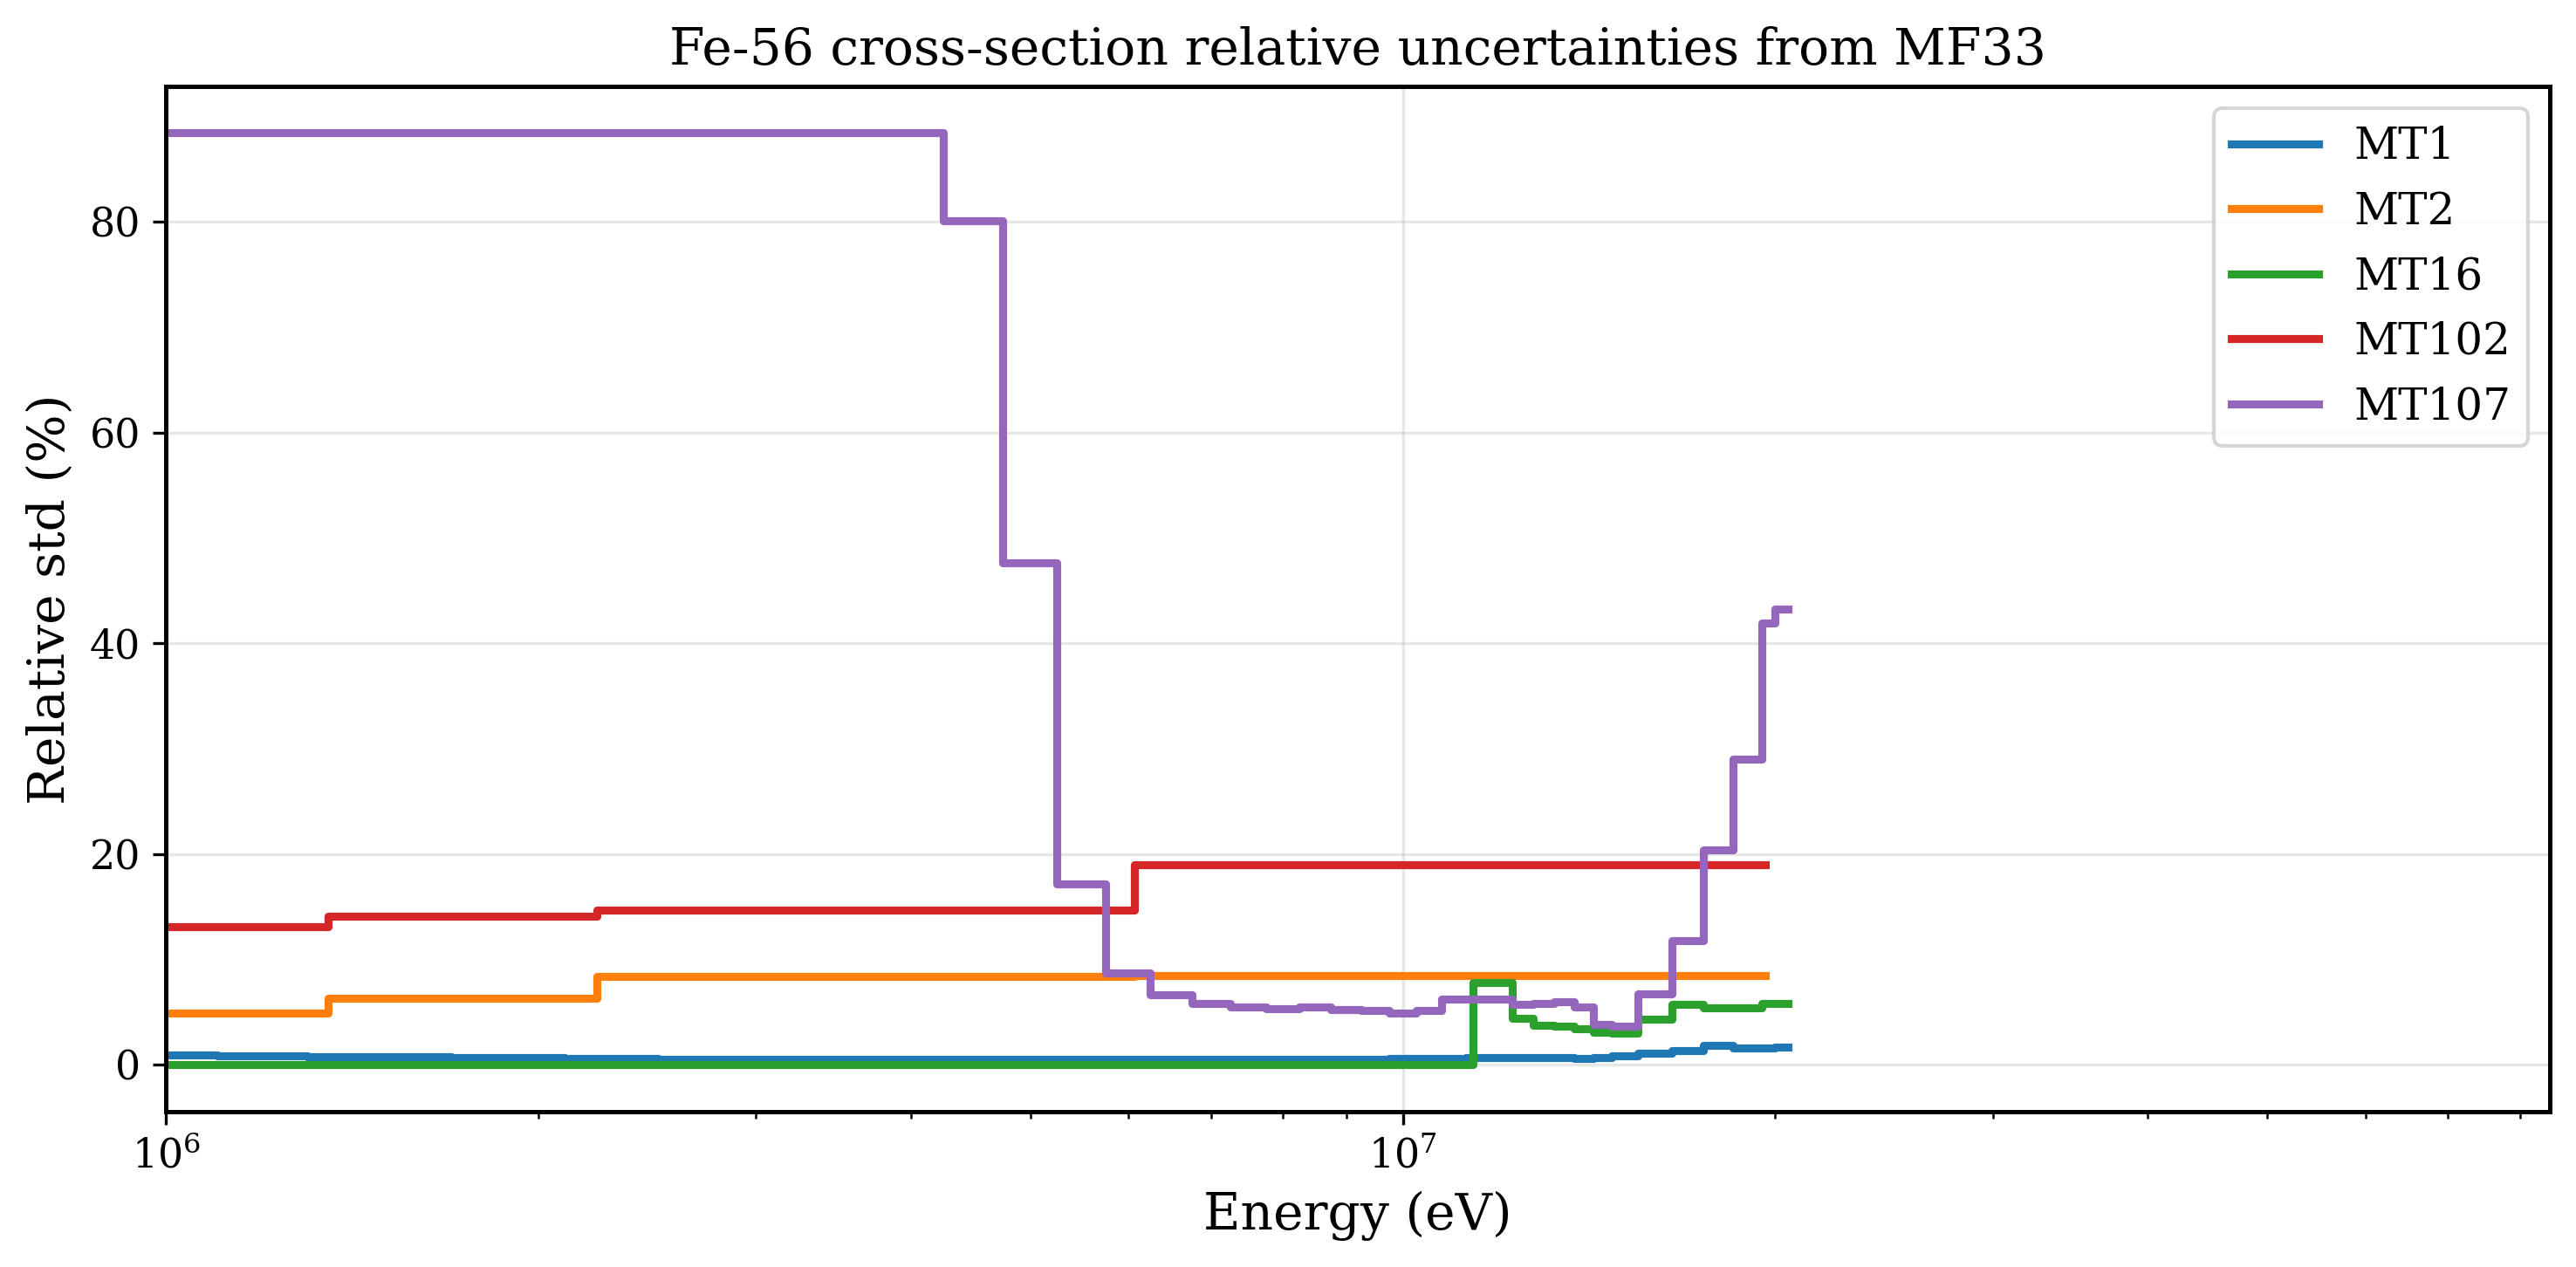

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot relative std for several reactions
for mt_num in [1, 2, 16, 102, 107]:
    if mt_num not in mf33.sections:
        continue
    mt_sec = mf33.sections[mt_num]
    if mt_sec.is_lumped_component:
        continue
    cov = mt_sec.to_xs_covmat()
    # Find diagonal block
    for i in range(len(cov.matrices)):
        if cov.reaction_rows[i] == mt_num and cov.reaction_cols[i] == mt_num:
            m = cov.matrices[i]
            grid = np.array(cov.energy_grids[i])
            diag = m.diagonal()
            rel_std = np.sqrt(np.maximum(diag, 0)) * 100  # percent
            # Use full grid (G+1 edges) and repeat last value so the final bin is visible
            y = np.append(rel_std, rel_std[-1])
            ax.step(grid, y, where='post', label=f'MT{mt_num}')
            break

ax.set_xscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Relative std (%)')
ax.set_title('Fe-56 cross-section relative uncertainties from MF33')
ax.set_xlim(1e6, None)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()